In [1]:
import os
try:
    print(file_path)
except:
    file_path = os.path.abspath('')
    os.chdir(os.path.dirname(file_path))
    print(file_path)

/home/mrzaizai2k/code_Bao/stock_price_4_fun/todo_assistant


In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Full data

In [3]:
data_path="data/all_tasks.json" 

In [4]:
df = pd.DataFrame(json.load(open(data_path, 'r')))
print(f"Total tasks: {len(df)}\nInfo:\n{df.info()}\nFirst task:\n{df.iloc[0]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1557 entries, 0 to 1556
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   @odata.etag                    1557 non-null   object
 1   importance                     1557 non-null   object
 2   isReminderOn                   1557 non-null   bool  
 3   status                         1557 non-null   object
 4   title                          1557 non-null   object
 5   createdDateTime                1557 non-null   object
 6   lastModifiedDateTime           1557 non-null   object
 7   hasAttachments                 1557 non-null   bool  
 8   categories                     1557 non-null   object
 9   id                             1557 non-null   object
 10  body                           1557 non-null   object
 11  completedDateTime              1415 non-null   object
 12  list_name                      1557 non-null   object
 13  lis

In [5]:
def safe_len(x):
    return len(x) if (x is not None and not (isinstance(x, float) and pd.isna(x)) and hasattr(x, '__len__')) else 0

try:
    no_subtasks = len(df[df['checklistItems'].apply(safe_len) == 0])
    print(f"\nTasks with no subtasks: {no_subtasks} ({no_subtasks/len(df)*100:.2f}%)")
except Exception as e:
    print(f"Error in subtasks: {e}")
for col, name in [('status', 'Status'), ('importance', 'Importance')]:
    try:
        print(f"\nTasks by {name}:\n{df[col].value_counts()}")
    except KeyError:
        print(f"\nTasks by {name}: {name} column not found")


Tasks with no subtasks: 1092 (70.13%)

Tasks by Status:
status
completed     1415
notStarted     142
Name: count, dtype: int64

Tasks by Importance:
importance
normal    1341
high       216
Name: count, dtype: int64


In [6]:
def checklist_completion_rate(x):
    if not isinstance(x, (list, tuple)) or not x:
        return None
    return sum(1 for i in x if i.get('isChecked', False)) / len(x) * 100

try:
    df['checklist_completion_rate'] = df['checklistItems'].apply(checklist_completion_rate)
    tasks_with_checklists = len(df[df['checklistItems'].apply(lambda x: isinstance(x, (list, tuple)) and len(x) > 0)])
    print(f"\nAvg checklist completion: {df['checklist_completion_rate'].mean(skipna=True):.2f}%")
    print(f"Tasks with checklists: {tasks_with_checklists} ({tasks_with_checklists/len(df)*100:.2f}%)")
except Exception as e:
    print(f"Error in checklist rate: {e}")

try:
    df['createdDateTime'] = pd.to_datetime(df['createdDateTime'], utc=True)
    df['lastModifiedDateTime'] = pd.to_datetime(df['lastModifiedDateTime'], utc=True)
    df['time_to_modify'] = (df['lastModifiedDateTime'] - df['createdDateTime']).dt.total_seconds() / 3600
    print(f"Avg time to modify (hours): {df['time_to_modify'].mean(skipna=True):.2f}")
except Exception as e:
    print(f"Error in time to modify: {e}")


Avg checklist completion: 36.10%
Tasks with checklists: 465 (29.87%)
Avg time to modify (hours): 364.88


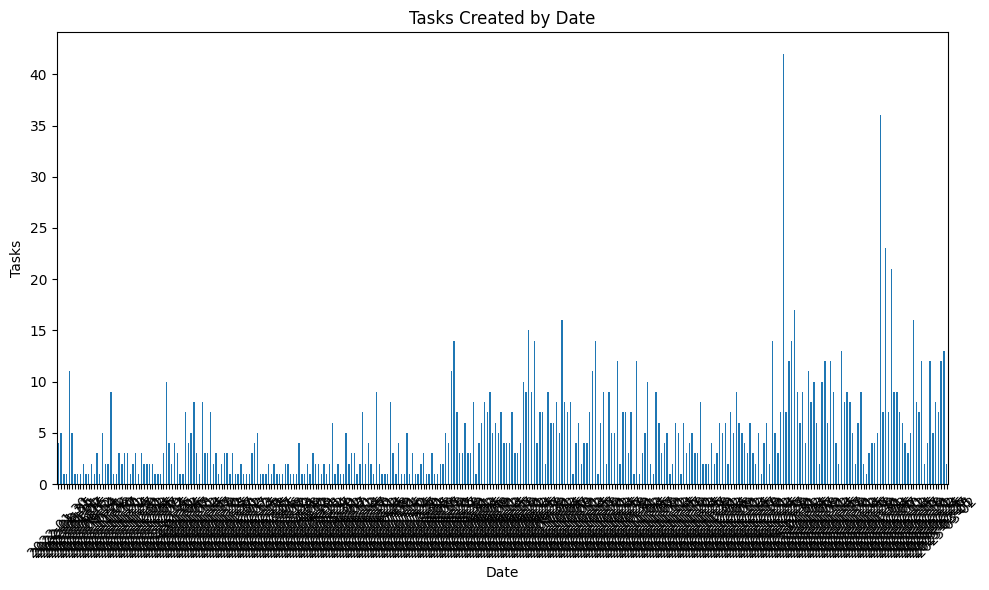

In [7]:
plt.figure(figsize=(10, 6))
df['createdDateTime'].dt.date.value_counts().sort_index().plot(kind='bar')
plt.title('Tasks Created by Date'); plt.xlabel('Date'); plt.ylabel('Tasks')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

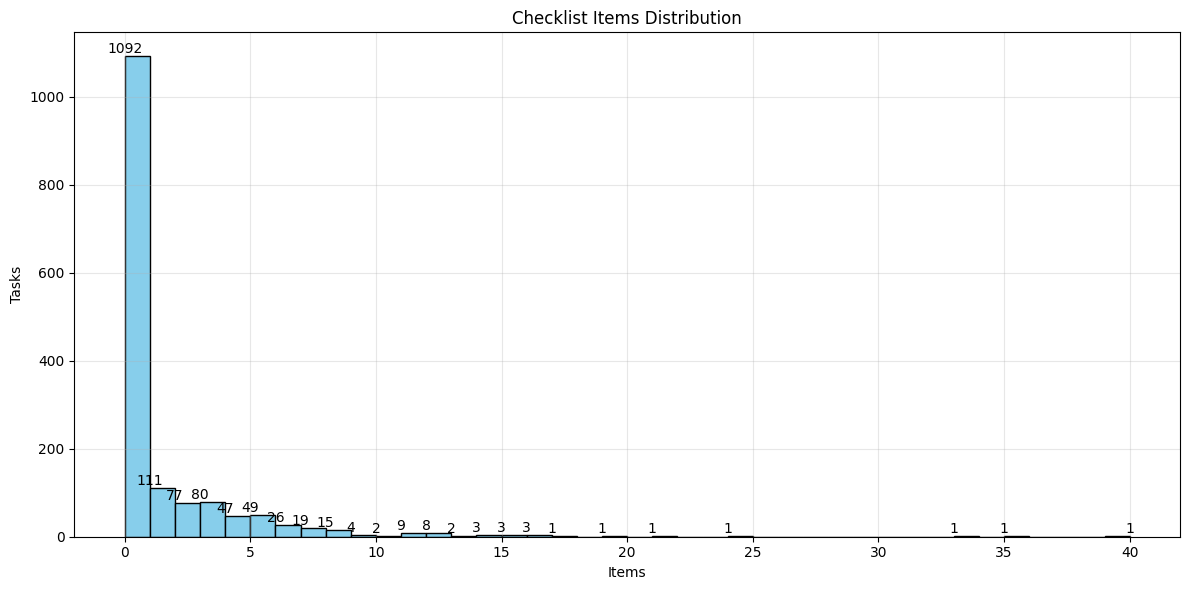


Checklist Stats: Avg: 1.25, Max: 40


In [8]:
plt.figure(figsize=(12, 6))
checklist_counts = df['checklistItems'].apply(safe_len)
checklist_counts.hist(bins=range(0, max(checklist_counts.max() + 1, 5)), edgecolor='black', color='skyblue')
plt.title('Checklist Items Distribution'); plt.xlabel('Items'); plt.ylabel('Tasks'); plt.grid(True, alpha=0.3)
for i in range(max(checklist_counts.max() + 1, 5)):
    if (count := sum(checklist_counts == i)) > 0:
        plt.text(i, count, str(count), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f"\nChecklist Stats: Avg: {checklist_counts.mean():.2f}, Max: {checklist_counts.max()}")

In [9]:
for col, name in [('isReminderOn', 'reminders'), ('hasAttachments', 'attachments')]:
    try:
        count = len(df[df[col] == True])
        print(f"\nTasks with {name}: {count} ({count/len(df)*100:.2f}%)")
    except KeyError:
        print(f"\nTasks with {name}: '{col}' not found")


Tasks with reminders: 27 (1.73%)

Tasks with attachments: 1 (0.06%)



Correlation Matrix:
                            creation_to_completion  creation_to_reminder  \
creation_to_completion                   1.000000              0.971950   
creation_to_reminder                     0.971950              1.000000   
time_to_modify                           0.901708              0.936295   
checklist_completion_rate                0.161036              0.100741   

                           time_to_modify  checklist_completion_rate  
creation_to_completion           0.901708                   0.161036  
creation_to_reminder             0.936295                   0.100741  
time_to_modify                   1.000000                   0.150715  
checklist_completion_rate        0.150715                   1.000000  


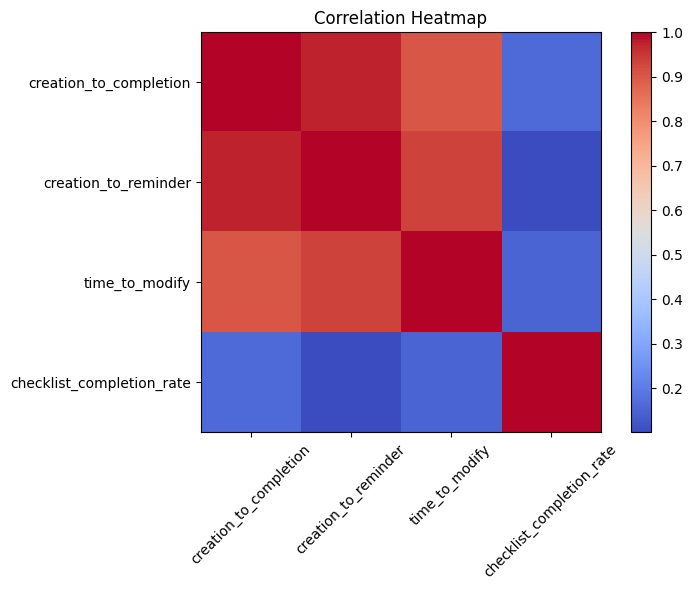

In [10]:
try:
    df['completedDateTime'] = pd.to_datetime(df['completedDateTime'].apply(lambda x: x['dateTime'] if isinstance(x, dict) else x), utc=True)
    df['reminderDateTime'] = pd.to_datetime(df['reminderDateTime'].apply(lambda x: x['dateTime'] if isinstance(x, dict) else x), utc=True)
    df['creation_to_completion'] = (df['completedDateTime'] - df['createdDateTime']).dt.total_seconds() / 3600
    df['creation_to_reminder'] = (df['reminderDateTime'] - df['createdDateTime']).dt.total_seconds() / 3600
    numeric_cols = ['creation_to_completion', 'creation_to_reminder', 'time_to_modify', 'checklist_completion_rate']
    correlation_matrix = df[numeric_cols].corr()
    print("\nCorrelation Matrix:\n", correlation_matrix)
    
    plt.figure(figsize=(8, 6))
    plt.imshow(correlation_matrix, cmap='coolwarm'); plt.colorbar()
    plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
    plt.yticks(range(len(numeric_cols)), numeric_cols)
    plt.title('Correlation Heatmap'); plt.tight_layout(); plt.show()
except Exception as e:
    print(f"Error in correlation: {e}")

# Remove unneccesary tasks

- Tasks thas has no subtasks
- Remove columns


In [12]:
df = pd.DataFrame(json.load(open(data_path, 'r')))
# Remove specified columns
columns_to_drop = ['isReminderOn', 'status', 'lastModifiedDateTime', 'hasAttachments', 'categories', 'id']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
print(f"Total tasks: {len(df)}\nInfo:\n{df.info()}\nFirst task:\n{df.iloc[0]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1557 entries, 0 to 1556
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   @odata.etag                    1557 non-null   object
 1   importance                     1557 non-null   object
 2   title                          1557 non-null   object
 3   createdDateTime                1557 non-null   object
 4   body                           1557 non-null   object
 5   completedDateTime              1415 non-null   object
 6   list_name                      1557 non-null   object
 7   list_id                        1557 non-null   object
 8   dueDateTime                    424 non-null    object
 9   reminderDateTime               315 non-null    object
 10  checklistItems@odata.context   465 non-null    object
 11  checklistItems                 465 non-null    object
 12  linkedResources@odata.context  2 non-null      object
 13  lin

Half of the tasks is just a single title, not useful for training

In [13]:
try:
    # Condition for tasks to drop
    condition = (
        (df['reminderDateTime'].isna() | df['reminderDateTime'].apply(lambda x: x is None)) &
        (df.get('dueDateTime', pd.Series([None]*len(df))).isna() | df['dueDateTime'].apply(lambda x: x is None)) &
        (df['checklistItems'].apply(safe_len) == 0)
    )
    tasks_to_drop = len(df[condition])
    print(f"\nTasks with no reminder, due date, and subtasks to drop: {tasks_to_drop} ({tasks_to_drop/len(df)*100:.2f}%)")
    
    # Drop the tasks
    df = df[~condition].copy()
    print(f"Tasks remaining after filtering: {len(df)} ({len(df)/len(df)*100:.2f}% of original)")
except Exception as e:
    print(f"Error in filtering tasks: {e}")


Tasks with no reminder, due date, and subtasks to drop: 766 (49.20%)
Tasks remaining after filtering: 791 (100.00% of original)


Check duplicate tasks
- Duplicate titles
- Duplicate Checklist

In [14]:
try:
    # Convert checklistItems to tuple of frozensets for hashable comparison
    df['checklist_tuple'] = df['checklistItems'].apply(lambda x: tuple(frozenset(d.items()) for d in x) if isinstance(x, list) else tuple())
    # Identify duplicates based on title and checklist_tuple
    duplicates = df.duplicated(subset=['title', 'checklist_tuple'], keep=False)
    duplicate_count = duplicates.sum()
    print(f"\nNumber of tasks with duplicate title and subtasks: {duplicate_count}")
    
    # Show some duplicate examples
    if duplicate_count > 0:
        print("\nExamples of duplicate tasks:")
        dup_df = df[duplicates].sort_values('title')
        print(dup_df[['title', 'checklistItems']].head(25))
except Exception as e:
    print(f"Error in counting duplicates: {e}")


Number of tasks with duplicate title and subtasks: 109

Examples of duplicate tasks:
                 title                                     checklistItems
343  **JANUARY GOALS**  [{'displayName': 'Có giáo trình chi tiết và tậ...
344  **JANUARY GOALS**  [{'displayName': 'Có giáo trình chi tiết và tậ...
241    Call my parents                                                NaN
465    Call my parents                                                NaN
731    Call my parents                                                NaN
766    Call my parents                                                NaN
13             Cắt tóc                                                NaN
571            Cắt tóc                                                NaN
168            Cắt tóc                                                NaN
933        Do the wash                                                NaN
805        Do the wash                                                NaN
875        Do the wash    

In [15]:
try:
    original_len = len(df)
    df_no_dup_titles = df.drop_duplicates(subset=['title'], keep='first')
    removed_count = original_len - len(df_no_dup_titles)
    print(f"\nRemoved {removed_count} tasks with duplicate titles")
    print(f"Remaining tasks: {len(df_no_dup_titles)}")
    # Update df to the filtered version
    df = df_no_dup_titles.drop(columns=['checklist_tuple'])  # Clean up temporary column
except Exception as e:
    print(f"Error in removing duplicate titles: {e}")


Removed 106 tasks with duplicate titles
Remaining tasks: 685


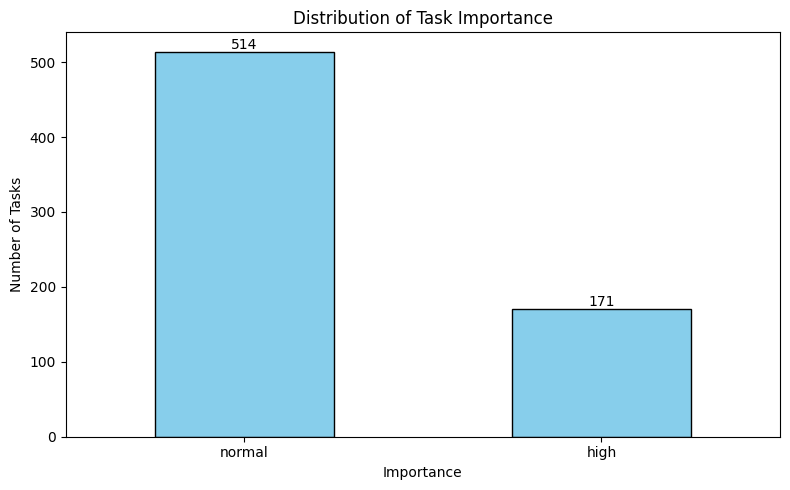


Importance Distribution:
importance
normal    514
high      171
Name: count, dtype: int64


In [16]:
try:
    plt.figure(figsize=(8, 5))
    importance_counts = df['importance'].value_counts()
    importance_counts.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Distribution of Task Importance')
    plt.xlabel('Importance')
    plt.ylabel('Number of Tasks')
    plt.xticks(rotation=0)
    for i, v in enumerate(importance_counts):
        plt.text(i, v, str(v), ha='center', va='bottom')
    plt.tight_layout()
    plt.show()
    print(f"\nImportance Distribution:\n{importance_counts}")
except KeyError:
    print("\nImportance Distribution: 'importance' column not found")
except Exception as e:
    print(f"Error in importance distribution: {e}")

In [17]:
def checklist_completion_rate(x):
    if not isinstance(x, (list, tuple)) or not x:
        return None
    return sum(1 for i in x if i.get('isChecked', False)) / len(x) * 100

try:
    df['checklist_completion_rate'] = df['checklistItems'].apply(checklist_completion_rate)
    tasks_with_checklists = len(df[df['checklistItems'].apply(lambda x: isinstance(x, (list, tuple)) and len(x) > 0)])
    print(f"\nAvg checklist completion: {df['checklist_completion_rate'].mean(skipna=True):.2f}%")
    print(f"Tasks with checklists: {tasks_with_checklists} ({tasks_with_checklists/len(df)*100:.2f}%)")
except Exception as e:
    print(f"Error in checklist rate: {e}")

try:
    df['createdDateTime'] = pd.to_datetime(df['createdDateTime'], utc=True)
    df['completedDateTime'] = pd.to_datetime(df['completedDateTime'].apply(lambda x: x['dateTime'] if isinstance(x, dict) else x), utc=True)
    df['time_to_complete'] = (df['completedDateTime'] - df['createdDateTime']).dt.total_seconds() / 3600
    print(f"Avg time to complete (hours): {df['time_to_complete'].mean(skipna=True):.2f}")
except Exception as e:
    print(f"Error in time to complete: {e}")


Avg checklist completion: 39.34%
Tasks with checklists: 423 (61.75%)
Avg time to complete (hours): 342.65


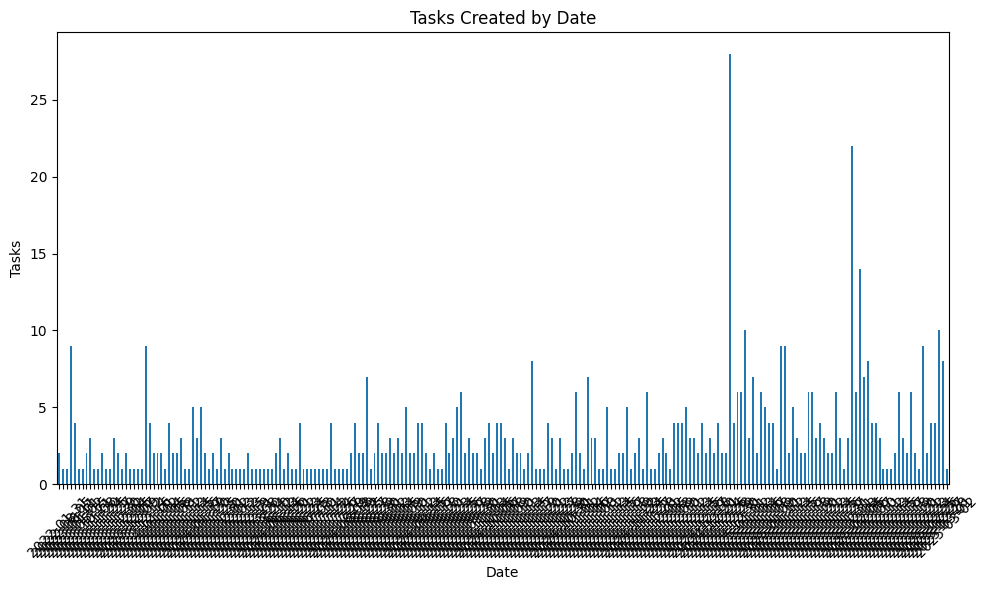

In [18]:
plt.figure(figsize=(10, 6))
df['createdDateTime'].dt.date.value_counts().sort_index().plot(kind='bar')
plt.title('Tasks Created by Date'); plt.xlabel('Date'); plt.ylabel('Tasks')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

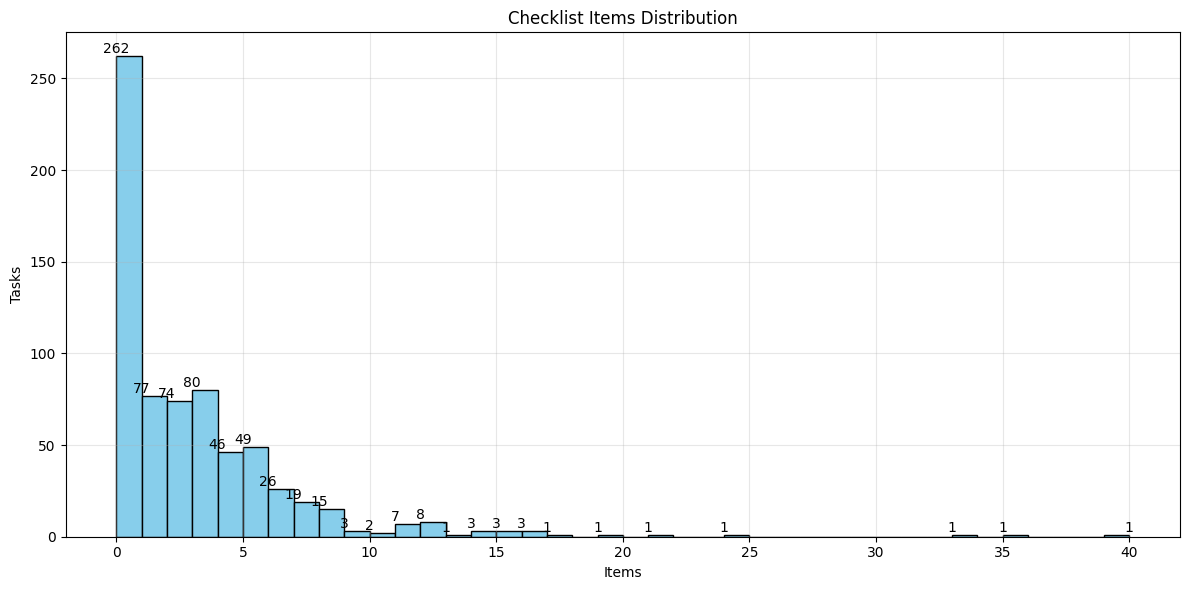


Checklist Stats: Avg: 2.72, Max: 40


In [19]:
plt.figure(figsize=(12, 6))
checklist_counts = df['checklistItems'].apply(safe_len)
checklist_counts.hist(bins=range(0, max(checklist_counts.max() + 1, 5)), edgecolor='black', color='skyblue')
plt.title('Checklist Items Distribution'); plt.xlabel('Items'); plt.ylabel('Tasks'); plt.grid(True, alpha=0.3)
for i in range(max(checklist_counts.max() + 1, 5)):
    if (count := sum(checklist_counts == i)) > 0:
        plt.text(i, count, str(count), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f"\nChecklist Stats: Avg: {checklist_counts.mean():.2f}, Max: {checklist_counts.max()}")


Analysis of tasks with subtasks only (Total: 423):
Tasks by importance:
importance
normal    284
high      139
Name: count, dtype: int64
Avg checklist completion: 39.34%
Avg time to complete (hours): 551.40


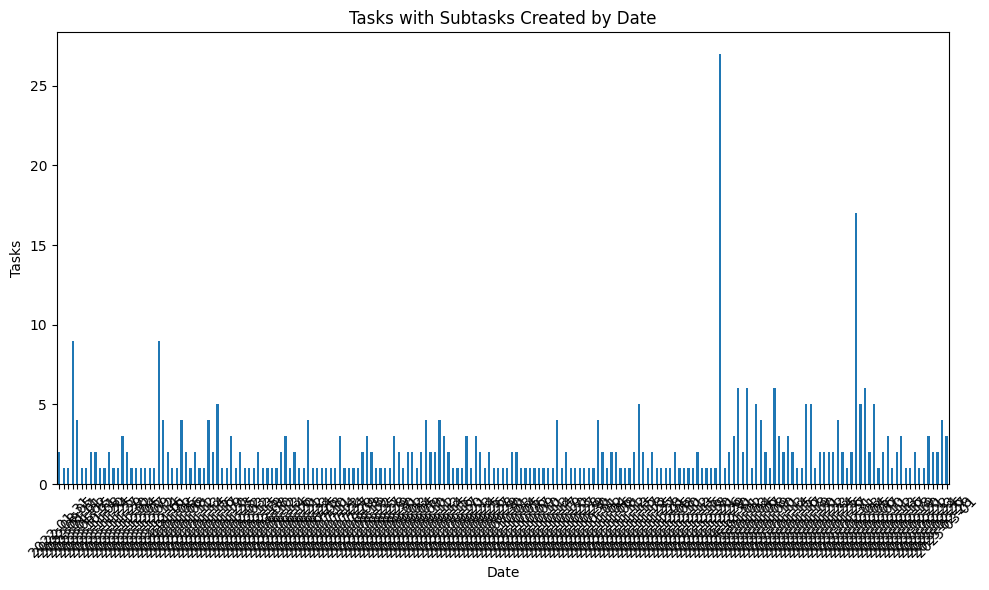

In [20]:
try:
    df_with_subtasks = df[df['checklistItems'].apply(safe_len) > 0].copy()
    print(f"\nAnalysis of tasks with subtasks only (Total: {len(df_with_subtasks)}):")
    
    # Re-run key analyses
    print(f"Tasks by importance:\n{df_with_subtasks['importance'].value_counts()}")
    df_with_subtasks['checklist_completion_rate'] = df_with_subtasks['checklistItems'].apply(checklist_completion_rate)
    print(f"Avg checklist completion: {df_with_subtasks['checklist_completion_rate'].mean(skipna=True):.2f}%")
    print(f"Avg time to complete (hours): {df_with_subtasks['time_to_complete'].mean(skipna=True):.2f}")
    
    plt.figure(figsize=(10, 6))
    df_with_subtasks['createdDateTime'].dt.date.value_counts().sort_index().plot(kind='bar')
    plt.title('Tasks with Subtasks Created by Date'); plt.xlabel('Date'); plt.ylabel('Tasks')
    plt.xticks(rotation=45); plt.tight_layout(); plt.show()
except Exception as e:
    print(f"Error in subtasks-only analysis: {e}")

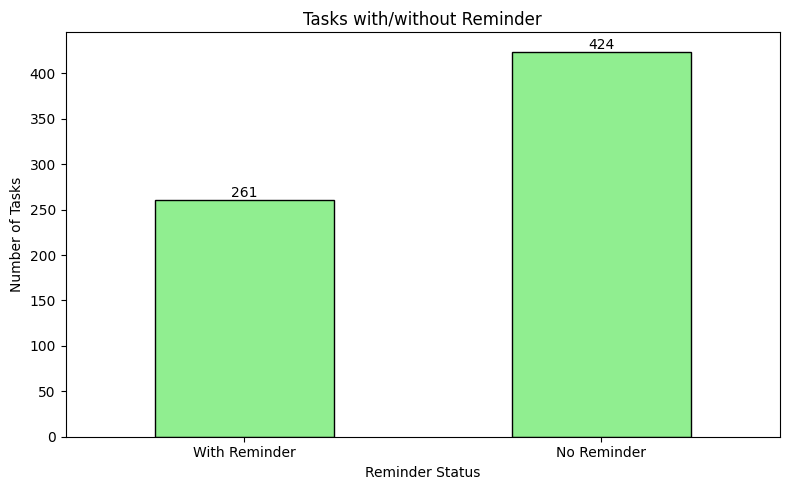


Reminder Distribution:
With Reminder    261
No Reminder      424
dtype: int64


In [21]:
# Tasks with/without reminderDateTime
try:
    has_reminder = df['reminderDateTime'].notna() & df['reminderDateTime'].apply(lambda x: x is not None)
    reminder_counts = pd.Series([has_reminder.sum(), (~has_reminder).sum()], index=['With Reminder', 'No Reminder'])
    plt.figure(figsize=(8, 5))
    reminder_counts.plot(kind='bar', color='lightgreen', edgecolor='black')
    plt.title('Tasks with/without Reminder')
    plt.xlabel('Reminder Status')
    plt.ylabel('Number of Tasks')
    plt.xticks(rotation=0)
    for i, v in enumerate(reminder_counts):
        plt.text(i, v, str(v), ha='center', va='bottom')
    plt.tight_layout()
    plt.show()
    print(f"\nReminder Distribution:\n{reminder_counts}")
except Exception as e:
    print(f"Error in reminder distribution: {e}")

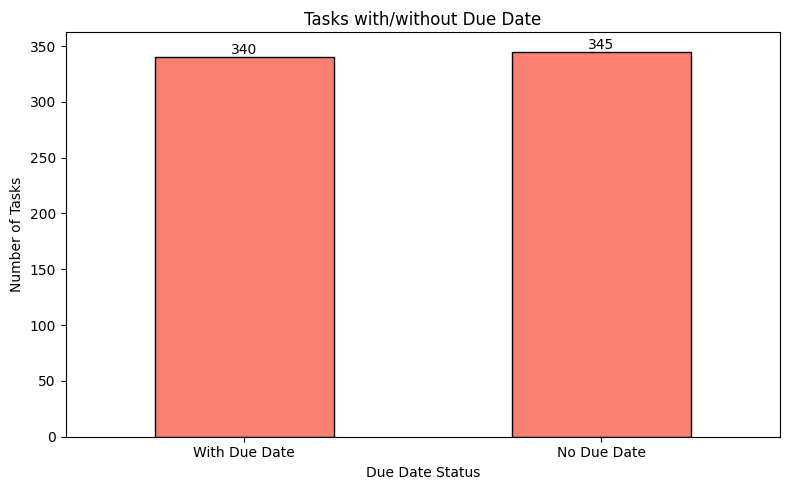


Due Date Distribution:
With Due Date    340
No Due Date      345
dtype: int64


In [22]:
# Tasks with/without dueDateTime
try:
    has_due = df.get('dueDateTime', pd.Series([None]*len(df))).notna() & df.get('dueDateTime').apply(lambda x: x is not None)
    due_counts = pd.Series([has_due.sum(), (~has_due).sum()], index=['With Due Date', 'No Due Date'])
    plt.figure(figsize=(8, 5))
    due_counts.plot(kind='bar', color='salmon', edgecolor='black')
    plt.title('Tasks with/without Due Date')
    plt.xlabel('Due Date Status')
    plt.ylabel('Number of Tasks')
    plt.xticks(rotation=0)
    for i, v in enumerate(due_counts):
        plt.text(i, v, str(v), ha='center', va='bottom')
    plt.tight_layout()
    plt.show()
    print(f"\nDue Date Distribution:\n{due_counts}")
except Exception as e:
    print(f"Error in due date distribution: {e}")


Title Word Count Stats:
Average: 5.01
Median: 4.00
Max: 29

Subtask Word Count Stats (total words across all subtasks per task):
Average: 0.00
Median: 0.00
Max: 0


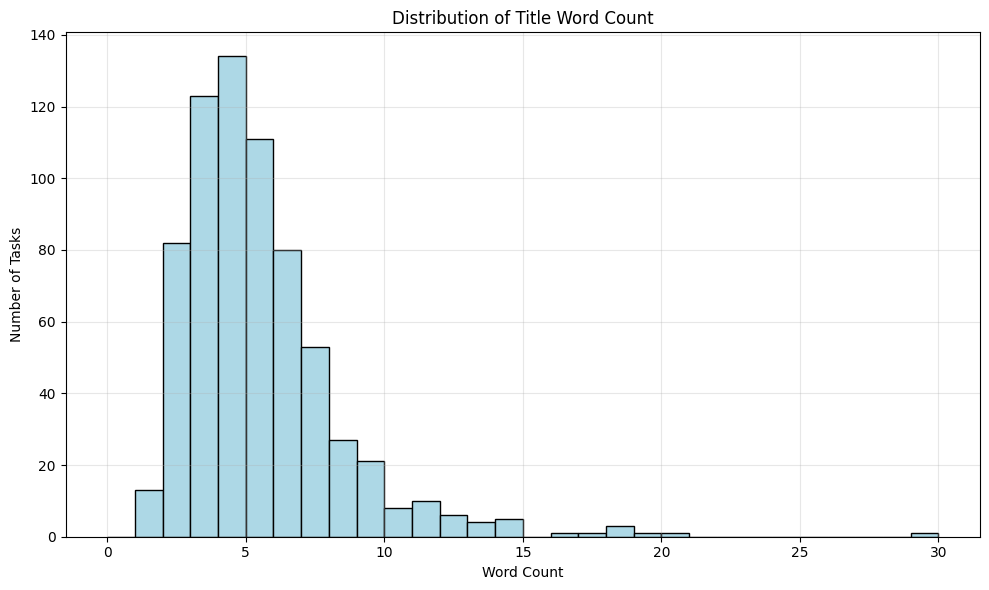

In [23]:
# Word length analysis in titles and subtasks
try:
    # Title word length
    df['title_word_count'] = df['title'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)
    print(f"\nTitle Word Count Stats:")
    print(f"Average: {df['title_word_count'].mean():.2f}")
    print(f"Median: {df['title_word_count'].median():.2f}")
    print(f"Max: {df['title_word_count'].max()}")

    # Subtask word length (assuming checklistItems contains dicts with 'title' or similar)
    def subtask_word_count(items):
        if not isinstance(items, (list, tuple)) or not items:
            return 0
        return sum(len(str(item.get('title', '')).split()) for item in items if pd.notna(item.get('title')))

    df['subtask_word_count'] = df['checklistItems'].apply(subtask_word_count)
    print(f"\nSubtask Word Count Stats (total words across all subtasks per task):")
    print(f"Average: {df['subtask_word_count'].mean():.2f}")
    print(f"Median: {df['subtask_word_count'].median():.2f}")
    print(f"Max: {df['subtask_word_count'].max()}")

    # Plot title word count distribution
    plt.figure(figsize=(10, 6))
    df['title_word_count'].hist(bins=range(df['title_word_count'].max() + 2), color='lightblue', edgecolor='black')
    plt.title('Distribution of Title Word Count')
    plt.xlabel('Word Count')
    plt.ylabel('Number of Tasks')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Plot subtask word count distribution (if any subtasks exist)
    if df['subtask_word_count'].sum() > 0:
        plt.figure(figsize=(10, 6))
        df['subtask_word_count'].hist(bins=range(df['subtask_word_count'].max() + 2), color='lightcoral', edgecolor='black')
        plt.title('Distribution of Subtask Word Count per Task')
        plt.xlabel('Total Subtask Word Count')
        plt.ylabel('Number of Tasks')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f"Error in word length analysis: {e}")